
**Task:** Predict the selling price of used cars (Regression)
**Dataset:** `used_cars.csv`

In [36]:
#Import libraries and load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', '{:,.2f}'.format)

df = pd.read_csv('used_cars.csv')

# Clean price and milage: remove symbols - convert to float
df['price']  = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)
df['milage'] = df['milage'].str.replace(' mi.', '', regex=False).str.replace(',', '', regex=False).astype(float)

print('Dataset loaded successfully!')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')

Dataset loaded successfully!
Shape: 4009 rows x 12 columns


## 1. Dataset Structure

In [37]:
# Number of rows and columns
print(f'Rows   : {df.shape[0]}')
print(f'Columns: {df.shape[1]}')

# Feature names and data types
print('\nFeature Names and Data Types:')
print(df.dtypes)

# First 5 rows
print('\nFirst 5 rows:')
df.head()

Rows   : 4009
Columns: 12

Feature Names and Data Types:
brand               str
model               str
model_year        int64
milage          float64
fuel_type           str
engine              str
transmission        str
ext_col             str
int_col             str
accident            str
clean_title         str
price           float64
dtype: object

First 5 rows:


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000.00",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"10,300.00"
1,Hyundai,Palisade SEL,2021,"34,742.00",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"38,005.00"
2,Lexus,RX 350 RX 350,2022,"22,372.00",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"54,598.00"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900.00",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"15,500.00"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835.00",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"34,999.00"


---
## 2. Data Distributions

In [38]:
# Numerical distributions
print('Numerical Distributions')
print(df[['model_year', 'milage', 'price']].describe().round(2))
print('\nSkewness:')
for col in ['model_year', 'milage', 'price']:
    print(f'  {col:12s}: {df[col].skew():.2f}')

Numerical Distributions
       model_year     milage        price
count    4,009.00   4,009.00     4,009.00
mean     2,015.52  64,717.55    44,553.19
std          6.10  52,296.60    78,710.64
min      1,974.00     100.00     2,000.00
25%      2,012.00  23,044.00    17,200.00
50%      2,017.00  52,775.00    31,000.00
75%      2,020.00  94,100.00    49,990.00
max      2,024.00 405,000.00 2,954,083.00

Skewness:
  model_year  : -1.09
  milage      : 1.16
  price       : 19.51


In [39]:
# Categorical distributions — top 5 per column
print('Categorical Distributions\n')
for col in ['brand', 'fuel_type', 'transmission', 'accident', 'clean_title']:
    counts = df[col].value_counts(dropna=False).head(5)
    pct    = (counts / len(df) * 100).round(2)
    print(f'--- {col.upper()} (unique values: {df[col].nunique()}) ---')
    print(pd.DataFrame({'Count': counts, 'Percent %': pct}))
    print()

Categorical Distributions

--- BRAND (unique values: 57) ---
               Count  Percent %
brand                          
Ford             386       9.63
BMW              375       9.35
Mercedes-Benz    315       7.86
Chevrolet        292       7.28
Porsche          201       5.01

--- FUEL_TYPE (unique values: 7) ---
               Count  Percent %
fuel_type                      
Gasoline        3309      82.54
Hybrid           194       4.84
NaN              170       4.24
E85 Flex Fuel    139       3.47
Diesel           116       2.89

--- TRANSMISSION (unique values: 62) ---
                                Count  Percent %
transmission                                    
A/T                              1037      25.87
8-Speed A/T                       406      10.13
Transmission w/Dual Shift Mode    398       9.93
6-Speed A/T                       362       9.03
6-Speed M/T                       248       6.19

--- ACCIDENT (unique values: 2) ---
                               

In [40]:
# Target variable distribution
print(' Target Variable: price ')
print(f'  Mean    : ${df["price"].mean():>12,.0f}')
print(f'  Median  : ${df["price"].median():>12,.0f}')
print(f'  Std Dev : ${df["price"].std():>12,.0f}')
print(f'  Min     : ${df["price"].min():>12,.0f}')
print(f'  Max     : ${df["price"].max():>12,.0f}')
print(f'  Skewness: {df["price"].skew():.2f}  (> 1 means right-skewed)')

log_price = np.log1p(df['price'])
print(f'\nAfter log(1+price) transformation:')
print(f'  Skewness: {log_price.skew():.2f}  (near-normal, better for modelling)')

 Target Variable: price 
  Mean    : $      44,553
  Median  : $      31,000
  Std Dev : $      78,711
  Min     : $       2,000
  Max     : $   2,954,083
  Skewness: 19.51  (> 1 means right-skewed)

After log(1+price) transformation:
  Skewness: 0.11  (near-normal, better for modelling)


---
## 3. Relationships

Pearson Correlation Matrix
            model_year  milage  price
model_year        1.00   -0.62   0.20
milage           -0.62    1.00  -0.31
price             0.20   -0.31   1.00


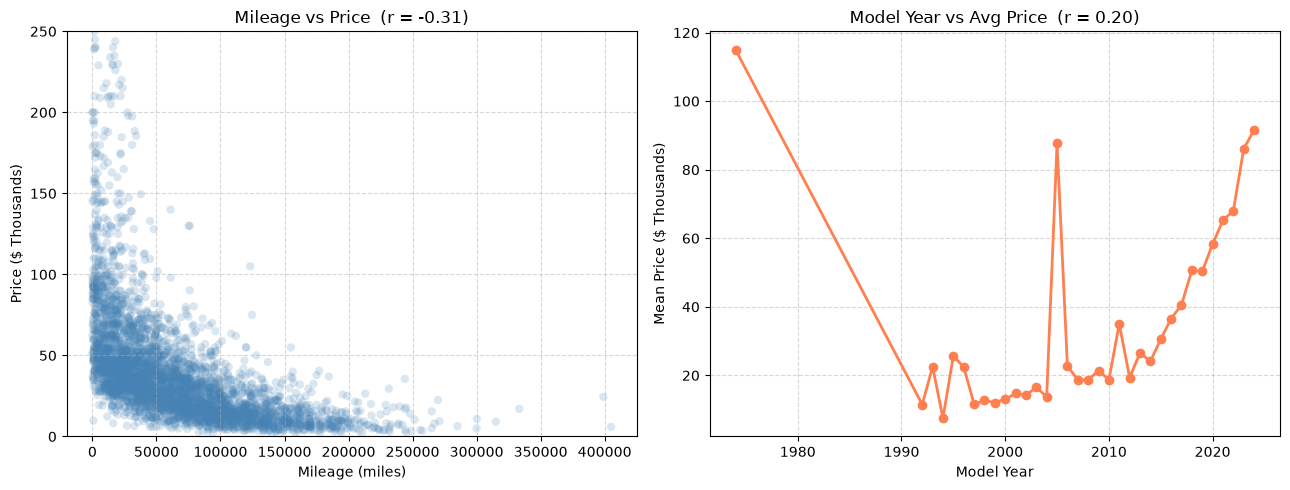


Accident History vs Price 
                                        Count  Mean Price  Median Price
accident                                                               
At least 1 accident or damage reported    986   28,832.00     20,900.00
None reported                            2910   49,638.00     35,668.00

Accident depreciation: -41.4%


In [41]:
# Pearson correlation matrix (feature-feature and feature-target)
print('Pearson Correlation Matrix')
corr = df[['model_year', 'milage', 'price']].corr().round(2)
print(corr)

# Scatter plots: feature vs target
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df['milage'], df['price'] / 1000, alpha=0.2, color='steelblue', edgecolors='none')
axes[0].set_title(f'Mileage vs Price  (r = {corr.loc["milage","price"]:.2f})')
axes[0].set_xlabel('Mileage (miles)')
axes[0].set_ylabel('Price ($ Thousands)')
axes[0].set_ylim(0, 250)
axes[0].grid(True, linestyle='--', alpha=0.5)

avg_by_year = df.groupby('model_year')['price'].mean() / 1000
axes[1].plot(avg_by_year.index, avg_by_year.values, marker='o', color='coral', linewidth=2)
axes[1].set_title(f'Model Year vs Avg Price  (r = {corr.loc["model_year","price"]:.2f})')
axes[1].set_xlabel('Model Year')
axes[1].set_ylabel('Mean Price ($ Thousands)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Categorical relationship
print('\nAccident History vs Price ')
acc = df.groupby('accident')['price'].agg(['count','mean','median']).round(0)
acc.columns = ['Count', 'Mean Price', 'Median Price']
print(acc)
no_acc  = df[df['accident']=='None reported']['price'].median()
has_acc = df[df['accident']=='At least 1 accident or damage reported']['price'].median()
print(f'\nAccident depreciation: {(has_acc - no_acc) / no_acc * 100:.1f}%')

---
## 4. Missing Values — Detection

In [42]:
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)
missing_df    = pd.DataFrame({'Missing Count': missing_count, 'Missing %': missing_pct})
missing_df    = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print('Missing Values')
print(missing_df)
print(f'\nTotal missing cells : {df.isnull().sum().sum()}')
print(f'Total rows affected : {df.isnull().any(axis=1).sum()}')

Missing Values
             Missing Count  Missing %
clean_title            596      14.87
fuel_type              170       4.24
accident               113       2.82

Total missing cells : 879
Total rows affected : 740


### Missing Value handling


In [43]:
print('Missing values before treatment:')
print(df[['fuel_type','accident','clean_title']].isnull().sum())
print()

# Option 1: Remove rows with any missing value
df_remove = df.dropna()
lost = len(df) - len(df_remove)
print(f'Option 1 - Remove (dropna):')
print(f'  Rows kept  : {len(df_remove)}  |  Rows lost: {lost} ({lost/len(df)*100:.1f}%)')
print(f'  Decision   : REJECTED — losing 18.5% of data weakens the model')
print()

# Option 2: Fill with mean / median / mode
df_mode = df.copy()
for col in ['fuel_type','accident','clean_title']:
    df_mode[col] = df_mode[col].fillna(df_mode[col].mode()[0])
print(f'Option 2 - Mode Imputation:')
print(f'  Missing after : {df_mode[["fuel_type","accident","clean_title"]].isnull().sum().sum()}')
print(f'  Decision      : REJECTED — blindly fills unverified titles as Yes (misleading)')
print()

# Option 3: Domain-guided imputation SELECTED
df_clean = df.copy()
df_clean['clean_title'] = df_clean['clean_title'].fillna('No')
df_clean['accident']    = df_clean['accident'].fillna('None reported')
elec = df_clean['engine'].str.contains('Electric', case=False, na=False)
df_clean.loc[df_clean['fuel_type'].isnull() & elec, 'fuel_type'] = 'Electric'
df_clean['fuel_type']   = df_clean['fuel_type'].fillna('Gasoline')
print(f'Option 3 - Domain-Guided Imputation  <-- SELECTED')
print(f'  Missing after : {df_clean[["fuel_type","accident","clean_title"]].isnull().sum().sum()}')
print(f'  Decision      : BEST — 0% data loss, context-aware fill based on domain knowledge')

Missing values before treatment:
fuel_type      170
accident       113
clean_title    596
dtype: int64

Option 1 - Remove (dropna):
  Rows kept  : 3269  |  Rows lost: 740 (18.5%)
  Decision   : REJECTED — losing 18.5% of data weakens the model

Option 2 - Mode Imputation:
  Missing after : 0
  Decision      : REJECTED — blindly fills unverified titles as Yes (misleading)

Option 3 - Domain-Guided Imputation  <-- SELECTED
  Missing after : 0
  Decision      : BEST — 0% data loss, context-aware fill based on domain knowledge


---
## 5. Duplicate Records — Detection

In [44]:
exact_dups = df.duplicated().sum()
near_dups  = df.duplicated(subset=['brand','model','model_year','milage','price']).sum()

print(f'Exact duplicate rows : {exact_dups}')
print(f'Near-duplicate rows  : {near_dups}  (same brand, model, year, milage, price)')

if exact_dups == 0 and near_dups == 0:
    print('\nResult: No duplicates found. All records are unique.')

Exact duplicate rows : 0
Near-duplicate rows  : 0  (same brand, model, year, milage, price)

Result: No duplicates found. All records are unique.


### Duplicate Records Treatment


In [45]:
dups = df_clean.duplicated().sum()
print(f'Duplicate rows: {dups}')

if dups > 0:
    df_clean = df_clean.drop_duplicates()
    print(f'Removed {dups} duplicates. Rows remaining: {len(df_clean)}')
else:
    print('No duplicates. All records are unique.')

Duplicate rows: 0
No duplicates. All records are unique.


---
## 6. Outliers & Invalid Records — Detection

In [46]:
print('Outlier Detection using IQR Rule ')
print('  Lower = Q1 - 1.5 x IQR     Upper = Q3 + 1.5 x IQR')
print()
for col in ['milage', 'price', 'model_year']:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col:12s} | [{lower:>12,.1f}, {upper:>10,.1f}] | Outliers: {n_out} ({n_out/len(df)*100:.1f}%)')

print('\nTop 5 Most Expensive Cars ')
top5 = df.nlargest(5, 'price')[['brand','model','model_year','price']]
print(top5.to_string(index=True))

print('\nAssessment:')
print('  Bugatti Veyron, Porsche Carrera GT -> GENUINE (verified hypercar prices)')
print('  2005 Maserati Quattroporte at $2,954,083 -> DATA ERROR (real value ~$15,000)')

Outlier Detection using IQR Rule 
  Lower = Q1 - 1.5 x IQR     Upper = Q3 + 1.5 x IQR

milage       | [   -83,540.0,  200,684.0] | Outliers: 69 (1.7%)
price        | [   -31,985.0,   99,175.0] | Outliers: 244 (6.1%)
model_year   | [     2,000.0,    2,032.0] | Outliers: 67 (1.7%)

Top 5 Most Expensive Cars 
            brand                    model  model_year        price
693      Maserati        Quattroporte Base        2005 2,954,083.00
229       Bugatti  Veyron 16.4 Grand Sport        2011 1,950,995.00
3046      Porsche          Carrera GT Base        2005 1,599,000.00
1356  Lamborghini       Aventador SVJ Base        2021   749,950.00
624   Rolls-Royce                 Cullinan        2022   695,000.00

Assessment:
  Bugatti Veyron, Porsche Carrera GT -> GENUINE (verified hypercar prices)
  2005 Maserati Quattroporte at $2,954,083 -> DATA ERROR (real value ~$15,000)


### Invalid Records Treatment


In [47]:
print('Impossible Value Checks ')
print(f'Price <= 0       : {(df_clean["price"] <= 0).sum()}')
print(f'Mileage < 0      : {(df_clean["milage"] < 0).sum()}')
print(f'Year < 1900      : {(df_clean["model_year"] < 1900).sum()}')

# Remove data entry error: 2005 Maserati at $2.95M (real value ~$15,000)
typo = ((df_clean['brand']=='Maserati') &
        (df_clean['model_year']==2005) &
        (df_clean['price'] > 1_000_000))
print(f'\nMaserati data entry error: {typo.sum()} row')
df_clean = df_clean[~typo].copy()
print(f'Removed. Rows remaining: {len(df_clean)}')

# Fix corrupt fuel_type using a valid-values whitelist
valid_fuel = ['Gasoline','Hybrid','Electric','E85 Flex Fuel','Diesel','Plug-In Hybrid','Other']
bad = (~df_clean['fuel_type'].isin(valid_fuel)).sum()
df_clean['fuel_type'] = df_clean['fuel_type'].apply(lambda x: x if x in valid_fuel else 'Other')
print(f'Corrupt fuel_type values fixed: {bad}')

Impossible Value Checks 
Price <= 0       : 0
Mileage < 0      : 0
Year < 1900      : 0

Maserati data entry error: 1 row
Removed. Rows remaining: 4008
Corrupt fuel_type values fixed: 47


### Outlier Treatment


In [48]:
Q1    = df_clean['price'].quantile(0.25)
Q3    = df_clean['price'].quantile(0.75)
upper = Q3 + 1.5 * (Q3 - Q1)
print(f'IQR upper fence: ${upper:,.2f}  |  Outliers: {(df_clean["price"] > upper).sum()} rows')
print()

print(f'Option 1 - Keep as-is:            Skewness = {df_clean["price"].skew():.2f}')
print(f'  -> Heavy tail damages model accuracy')

trimmed  = df_clean[df_clean['price'] <= upper]
rows_out = len(df_clean) - len(trimmed)
print(f'Option 2 - Remove outliers:       Removes {rows_out} rows ({rows_out/len(df_clean)*100:.1f}%)')
print(f'  -> Loses genuine luxury car data')

log_skew = np.log1p(df_clean['price']).skew()
print(f'Option 3 - Log Transform:         Skewness = {log_skew:.2f}  0% data loss  <-- SELECTED')
print(f'  -> Near-normal distribution, retains all data including luxury cars')

df_clean['log_price'] = np.log1p(df_clean['price'])

IQR upper fence: $99,137.50  |  Outliers: 243 rows

Option 1 - Keep as-is:            Skewness = 12.94
  -> Heavy tail damages model accuracy
Option 2 - Remove outliers:       Removes 243 rows (6.1%)
  -> Loses genuine luxury car data
Option 3 - Log Transform:         Skewness = 0.07  0% data loss  <-- SELECTED
  -> Near-normal distribution, retains all data including luxury cars


---
## 7. Class Imbalance

> This is a **regression** task — no class labels. We check the spread of the target variable across price segments.

In [49]:
bins   = [0, 25_000, 60_000, np.inf]
labels = ['Budget (< $25k)', 'Mid-Market ($25k-$60k)', 'Luxury (> $60k)']
df['price_tier'] = pd.cut(df['price'], bins=bins, labels=labels)

counts = df['price_tier'].value_counts().sort_index()
pct    = (counts / len(df) * 100).round(2)

print('Price Segment Distribution')
print(pd.DataFrame({'Count': counts, 'Percent %': pct}))
print('\nAll three segments are well represented — no severe imbalance.')

Price Segment Distribution
                        Count  Percent %
price_tier                              
Budget (< $25k)          1571      39.19
Mid-Market ($25k-$60k)   1725      43.03
Luxury (> $60k)           713      17.78

All three segments are well represented — no severe imbalance.


---
## 8. Visualizations

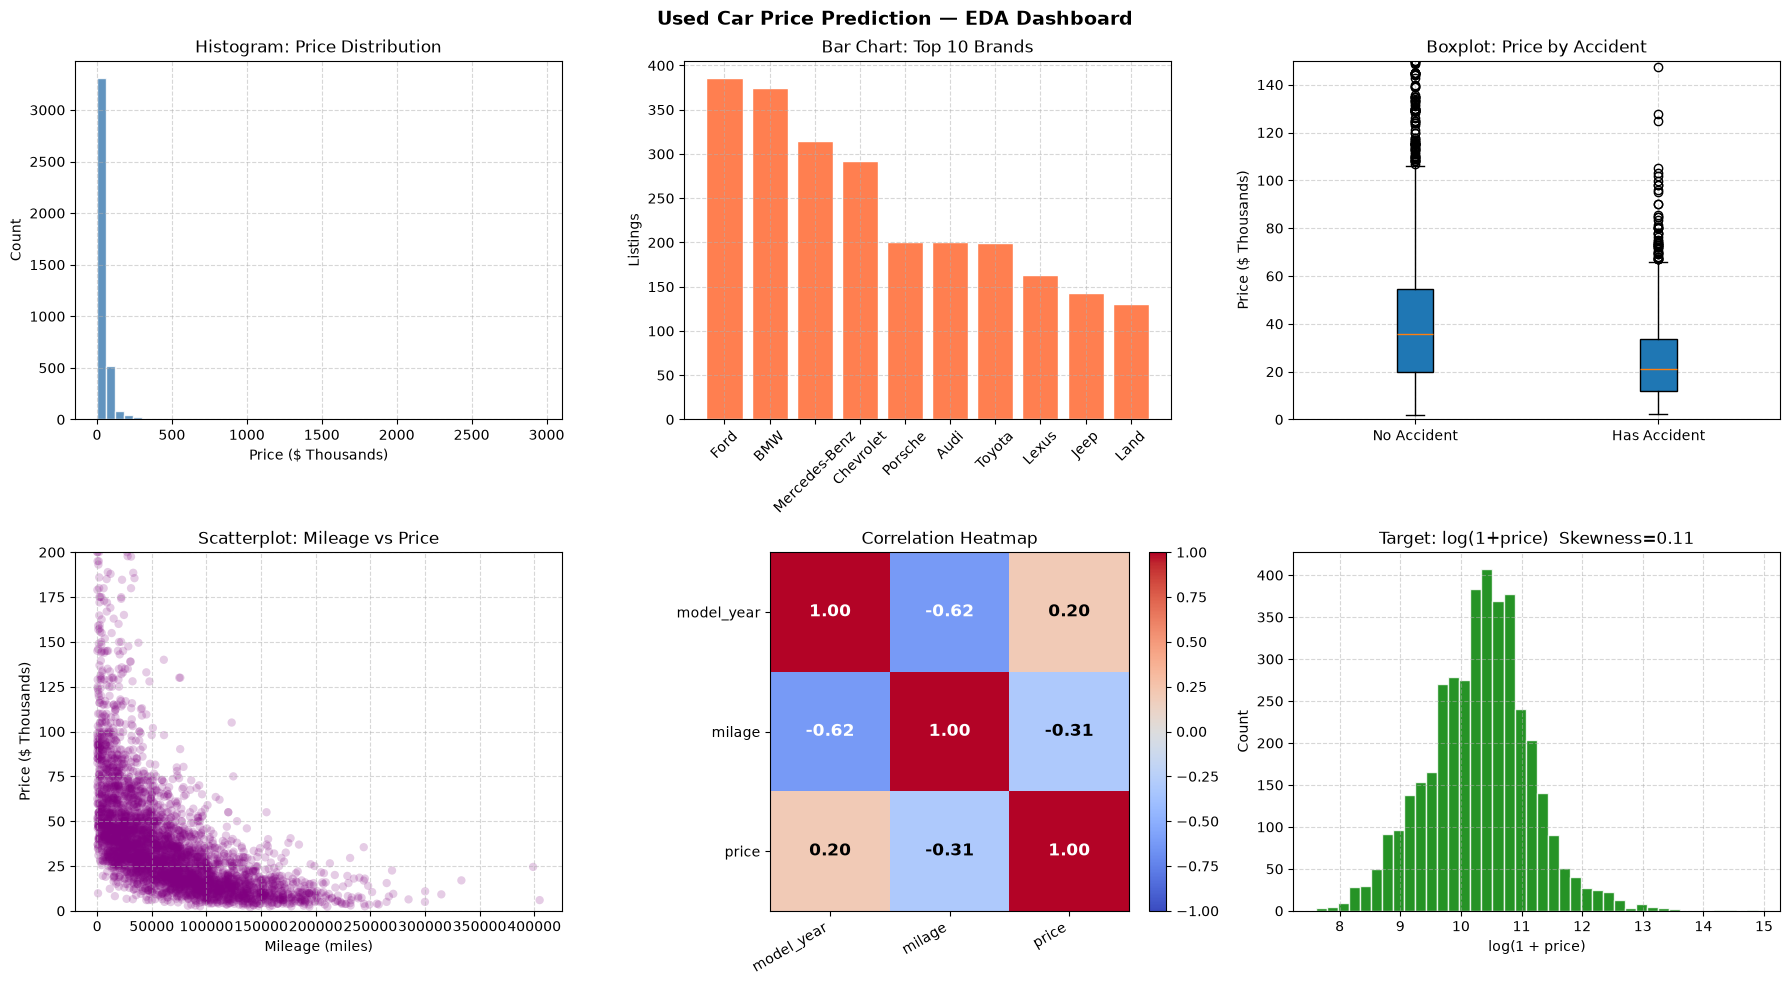

In [50]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Used Car Price Prediction — EDA Dashboard', fontsize=14, fontweight='bold')

# 1. Histogram — price distribution
axes[0,0].hist(df['price']/1000, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,0].set_title('Histogram: Price Distribution')
axes[0,0].set_xlabel('Price ($ Thousands)')
axes[0,0].set_ylabel('Count')
axes[0,0].grid(True, linestyle='--', alpha=0.5)

# 2. Bar chart — top 10 brands
top10 = df['brand'].value_counts().head(10)
axes[0,1].bar(top10.index, top10.values, color='coral', edgecolor='white')
axes[0,1].set_title('Bar Chart: Top 10 Brands')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].set_ylabel('Listings')
axes[0,1].grid(True, linestyle='--', alpha=0.5)

# 3. Boxplot — price by accident status
g_no  = df[df['accident']=='None reported']['price'].dropna()/1000
g_yes = df[df['accident']=='At least 1 accident or damage reported']['price'].dropna()/1000
axes[0,2].boxplot([g_no, g_yes], tick_labels=['No Accident','Has Accident'], patch_artist=True)
axes[0,2].set_title('Boxplot: Price by Accident')
axes[0,2].set_ylabel('Price ($ Thousands)')
axes[0,2].set_ylim(0, 150)
axes[0,2].grid(True, linestyle='--', alpha=0.5)

# 4. Scatterplot — mileage vs price
axes[1,0].scatter(df['milage'], df['price']/1000, alpha=0.2, color='purple', edgecolors='none')
axes[1,0].set_title('Scatterplot: Mileage vs Price')
axes[1,0].set_xlabel('Mileage (miles)')
axes[1,0].set_ylabel('Price ($ Thousands)')
axes[1,0].set_ylim(0, 200)
axes[1,0].grid(True, linestyle='--', alpha=0.5)

# 5. Correlation heatmap
corr = df[['model_year','milage','price']].corr()
im   = axes[1,1].imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
axes[1,1].set_xticks(range(len(corr.columns)))
axes[1,1].set_yticks(range(len(corr.columns)))
axes[1,1].set_xticklabels(corr.columns, rotation=30, ha='right')
axes[1,1].set_yticklabels(corr.columns)
fig.colorbar(im, ax=axes[1,1], fraction=0.046, pad=0.04)# color bar
for i in range(len(corr)):# adding numbers white and black
    for j in range(len(corr)):
        c = 'white' if abs(corr.iloc[i,j]) > 0.5 else 'black'
        axes[1,1].text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center',
                       fontsize=12, fontweight='bold', color=c)
axes[1,1].set_title('Correlation Heatmap')

# 6. Target distribution — log-transformed price
lp = np.log1p(df['price'])
axes[1,2].hist(lp, bins=40, color='green', edgecolor='white', alpha=0.85)
axes[1,2].set_title(f'Target: log(1+price)  Skewness={lp.skew():.2f}')
axes[1,2].set_xlabel('log(1 + price)')
axes[1,2].set_ylabel('Count')
axes[1,2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Categorical Encoding

In [51]:
# Binary encoding (0/1) for yes/no columns
df_clean['is_clean_title'] = (df_clean['clean_title'] == 'Yes').astype(int)
df_clean['has_accident']   = (df_clean['accident'] == 'At least 1 accident or damage reported').astype(int)
df_clean['is_manual']      = df_clean['transmission'].str.contains('M/T|Manual', case=False, na=False).astype(int)

print('Binary Encoding (0/1) preview:')
print(df_clean[['clean_title','is_clean_title','accident','has_accident','is_manual']].head(4))
print()

# One-hot(dummy variables) encoding for fuel_type (drop_first avoids multicollinearity)
fuel_dummies = pd.get_dummies(df_clean['fuel_type'], prefix='fuel', drop_first=True, dtype=int)
print('One-Hot Encoding — fuel_type columns:')
print(list(fuel_dummies.columns))
print()

# Brand grouping — 57 unique brands is too many for one-hot (56 columns)
# Group into 1 binary luxury flag instead
luxury = ['Porsche','Bugatti','Ferrari','Lamborghini','Rolls-Royce','Bentley',
          'McLaren','Maserati','Aston Martin','BMW','Mercedes-Benz','Audi',
          'Lexus','Jaguar','Cadillac','Lincoln','Genesis','INFINITI',
          'Tesla','Land Rover','Alfa Romeo','Volvo']
df_clean['is_luxury_brand'] = df_clean['brand'].isin(luxury).astype(int)
print(f'Brand grouping -> is_luxury_brand: {df_clean["is_luxury_brand"].value_counts().to_dict()}')

Binary Encoding (0/1) preview:
  clean_title  is_clean_title                                accident  \
0         Yes               1  At least 1 accident or damage reported   
1         Yes               1  At least 1 accident or damage reported   
2          No               0                           None reported   
3         Yes               1                           None reported   

   has_accident  is_manual  
0             1          0  
1             1          0  
2             0          0  
3             0          0  

One-Hot Encoding — fuel_type columns:
['fuel_E85 Flex Fuel', 'fuel_Electric', 'fuel_Gasoline', 'fuel_Hybrid', 'fuel_Other', 'fuel_Plug-In Hybrid']

Brand grouping -> is_luxury_brand: {0: 2222, 1: 1786}


## Numerical Scaling

In [52]:
col = df_clean['milage']
std_scaled = (col - col.mean()) / col.std()

mm_scaled  = (col - col.min())  / (col.max() - col.min())

print('Scaling Methods Comparison (milage column)')
print(f'{"Method":<20} {"Mean":>10} {"Std":>10} {"Min":>10} {"Max":>10}')
print(f'{"Original":<20} {col.mean():>10,.1f} {col.std():>10,.1f} {col.min():>10,.1f} {col.max():>10,.1f}')
print(f'{"Standardization":<20} {std_scaled.mean():>10.4f} {std_scaled.std():>10.4f} {std_scaled.min():>10.4f} {std_scaled.max():>10.4f}')
print(f'{"Min-Max":<20} {mm_scaled.mean():>10.4f} {mm_scaled.std():>10.4f} {mm_scaled.min():>10.4f} {mm_scaled.max():>10.4f}')
print()
print('Decision: Standardization SELECTED')
print('  Reason: Robust to extreme values. Min-Max is sensitive to outliers.')
print('  Note  : Mean and std computed on training data ONLY (see Train/Test Split step).')

Scaling Methods Comparison (milage column)
Method                     Mean        Std        Min        Max
Original               64,725.7   52,300.6      100.0  405,000.0
Standardization         -0.0000     1.0000    -1.2357     6.5061
Min-Max                  0.1596     0.1292     0.0000     1.0000

Decision: Standardization SELECTED
  Reason: Robust to extreme values. Min-Max is sensitive to outliers.
  Note  : Mean and std computed on training data ONLY (see Train/Test Split step).


## Feature Engineering

In [53]:
# car_age: more intuitive than raw model_year for price prediction
df_clean['car_age'] = 2026 - df_clean['model_year']

# mileage_per_year: annual usage intensity
# A 2-year-old car with 100k miles is very different from a 10-year-old with 100k
df_clean['mileage_per_year'] = (
    df_clean['milage'] /
    df_clean['car_age'].replace(0, 1)
)

print(' Engineered Features Preview ')
print(df_clean[['model_year','car_age','milage','mileage_per_year','log_price']].head(5))
print(f'\ncar_age range        : {df_clean["car_age"].min()} to {df_clean["car_age"].max()} years')
print(f'mileage_per_year mean: {df_clean["mileage_per_year"].mean():,.0f} miles/year')

 Engineered Features Preview 
   model_year  car_age    milage  mileage_per_year  log_price
0        2013       13 51,000.00          3,923.08       9.24
1        2021        5 34,742.00          6,948.40      10.55
2        2022        4 22,372.00          5,593.00      10.91
3        2015       11 88,900.00          8,081.82       9.65
4        2021        5  9,835.00          1,967.00      10.46

car_age range        : 2 to 52 years
mileage_per_year mean: 5,994 miles/year


## Feature Selection

In [54]:
df_final = pd.concat([df_clean, fuel_dummies], axis=1)

# FEATURES KEPT:
feature_cols = (['car_age', 'milage', 'mileage_per_year',
                 'is_luxury_brand', 'is_manual', 'is_clean_title', 'has_accident']
                + list(fuel_dummies.columns))

X = df_final[feature_cols].copy()
y = df_final['log_price'].copy()

print(f'Final Feature Matrix: {X.shape[0]} rows x {X.shape[1]} features')
print()
print('Features KEPT:')
for i, c in enumerate(X.columns, 1):
    print(f'  {i:2d}. {c}')

print()
print('Features REMOVED:')
print('  model_year   -> replaced by car_age')
print('  brand        -> replaced by is_luxury_brand (avoids 56 sparse columns)')
print('  model        -> 1,898 unique values, too high-cardinality')
print('  transmission -> replaced by is_manual flag')
print('  engine       -> unstructured text, hard to encode reliably')
print('  ext_col      -> cosmetic, low signal for price')
print('  int_col      -> cosmetic, low signal for price')

Final Feature Matrix: 4008 rows x 13 features

Features KEPT:
   1. car_age
   2. milage
   3. mileage_per_year
   4. is_luxury_brand
   5. is_manual
   6. is_clean_title
   7. has_accident
   8. fuel_E85 Flex Fuel
   9. fuel_Electric
  10. fuel_Gasoline
  11. fuel_Hybrid
  12. fuel_Other
  13. fuel_Plug-In Hybrid

Features REMOVED:
  model_year   -> replaced by car_age
  brand        -> replaced by is_luxury_brand (avoids 56 sparse columns)
  model        -> 1,898 unique values, too high-cardinality
  transmission -> replaced by is_manual flag
  engine       -> unstructured text, hard to encode reliably
  ext_col      -> cosmetic, low signal for price
  int_col      -> cosmetic, low signal for price


## Train/Test Split
Scaler fitted on **training data only** — prevents data leakage.

In [55]:
# 80% training, 20% testing — deterministic (random_state=42)
np.random.seed(42)

idx      = np.random.permutation(len(X))#randomly suffled row numbers
split    = int(0.8 * len(X))
X_train  = X.iloc[idx[:split]].copy()
X_test   = X.iloc[idx[split:]].copy()
y_train  = y.iloc[idx[:split]].copy()
y_test   = y.iloc[idx[split:]].copy()

print(f'Training set : {len(X_train)} rows ({len(X_train)/len(X)*100:.1f}%)')
print(f'Testing set  : {len(X_test)} rows  ({len(X_test)/len(X)*100:.1f}%)')

# Leakage-free standardization
# Step 1: compute mean and std from TRAINING data only
# Step 2: use those same values to scale BOTH train and test
cont_cols   = ['car_age', 'milage', 'mileage_per_year']
mu          = X_train[cont_cols].mean()
sigma       = X_train[cont_cols].std()

#Taking z-score foumulas for those two 
X_train[cont_cols] = (X_train[cont_cols] - mu) / sigma
X_test[cont_cols]  = (X_test[cont_cols]  - mu) / sigma

print()
print('Leakage Prevention Check')
print(f'Train milage mean : {X_train["milage"].mean():.4f}  (should be 0.0000)')
print(f'Train milage std  : {X_train["milage"].std():.4f}  (should be 1.0000)')
print(f'Test  milage mean : {X_test["milage"].mean():.4f}  (non-zero confirms test not used in fitting)')

print()
print()


print(f'Training samples : {len(X_train)}')
print(f'Features         : {X_train.shape[1]}')
print(f'Target variable  : log_price')

Training set : 3206 rows (80.0%)
Testing set  : 802 rows  (20.0%)

Leakage Prevention Check
Train milage mean : 0.0000  (should be 0.0000)
Train milage std  : 1.0000  (should be 1.0000)
Test  milage mean : -0.0630  (non-zero confirms test not used in fitting)


Training samples : 3206
Features         : 13
Target variable  : log_price


---
## Stage 6 and 7 — Shaji: Decision Tree Regressor
Run all earlier group notebook cells first. These sections reuse the EXISTING data split and features.


In [56]:
# Stage 6: Shaji — Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
import joblib
RANDOM_STATE = 42
assert all(v in globals() for v in ['X_train','X_test','y_train','y_test']), 'Run all existing cells through train/test split first.'
print('Using existing group train/test:', X_train.shape, X_test.shape)


Using existing group train/test: (3206, 13) (802, 13)


## 2. Evaluation metrics and validation
**MAE ($)**: average absolute prediction error in dollars (easily explained). **RMSE ($)**: penalizes large prediction errors more strongly. **R²**: proportion of target variation explained, which may be negative on unseen data. Your group trains on `log_price`, so we reverse with `np.expm1` to obtain interpretable dollar predictions. **5-fold KFold CV** is done on training rows only.


In [57]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
def regression_metrics(y_true_log, y_pred_log):
    actual = np.expm1(np.asarray(y_true_log))
    predicted = np.expm1(np.clip(np.asarray(y_pred_log), -30, 30))
    return {
        'MAE ($)': mean_absolute_error(actual,predicted),
        'RMSE ($)': np.sqrt(mean_squared_error(actual,predicted)),
        'R2 (log)': r2_score(y_true_log,y_pred_log),
        'MAE (log)': mean_absolute_error(y_true_log,y_pred_log)
    }
def cv_mae_dollars(estimator, X_data, y_data):
    # Out-of-fold dollar MAE, with same folds for fair comparisons.
    errors=[]
    for train_i, val_i in cv.split(X_data):
        est = estimator.__class__(**estimator.get_params())
        est.fit(X_data.iloc[train_i],y_data.iloc[train_i])
        p = est.predict(X_data.iloc[val_i])
        errors.append(regression_metrics(y_data.iloc[val_i],p)['MAE ($)'])
    return np.mean(errors), np.std(errors)


## 3. Baseline — unpruned Decision Tree vs simple benchmark
A Decision Tree splits the data into groups using questions such as “Is car age <= a threshold?”. Each terminal leaf predicts the mean training **log-price** for cars reaching that leaf. Unrestricted trees can memorize the training data (high variance). Compare against a dummy median baseline to establish whether the model has learned a useful pattern.

In [58]:
dummy = DummyRegressor(strategy='median')
dummy_cv_mean,dummy_cv_std = cv_mae_dollars(dummy,X_train,y_train)
base_tree = DecisionTreeRegressor(random_state=RANDOM_STATE)
base_cv_mean,base_cv_std = cv_mae_dollars(base_tree,X_train,y_train)
base_tree.fit(X_train,y_train)
base_train = regression_metrics(y_train,base_tree.predict(X_train))
base_test = regression_metrics(y_test,base_tree.predict(X_test))
print(f'Dummy 5-fold CV MAE: ${dummy_cv_mean:,.0f} ± ${dummy_cv_std:,.0f}')
print(f'Tree 5-fold CV MAE : ${base_cv_mean:,.0f} ± ${base_cv_std:,.0f}')
print('Tree train metrics:',base_train)
print('Tree test metrics: ',base_test)
print('Baseline tree depth:',base_tree.get_depth(), 'leaves:',base_tree.get_n_leaves())

Dummy 5-fold CV MAE: $26,302 ± $1,645
Tree 5-fold CV MAE : $25,054 ± $2,207
Tree train metrics: {'MAE ($)': 294.2386112454226, 'RMSE ($)': np.float64(2764.609234781429), 'R2 (log)': 0.9965155942101634, 'MAE (log)': 0.006784877001601108}
Tree test metrics:  {'MAE ($)': 27077.25748383304, 'RMSE ($)': np.float64(83554.46035560589), 'R2 (log)': 0.37146599925252033, 'MAE (log)': 0.5120836613668031}
Baseline tree depth: 31 leaves: 3132


## 4. Diagnose overfitting using learning complexity
Compare training and 5-fold CV dollar MAE as max depth increases. An extremely deep tree can have very small training error but substantially worse validation error. The best depth depends on data; read it from your actual output.

max_depth  Train MAE ($)  CV MAE ($)  CV std ($)
        2      20,103.00   20,384.00    1,225.00
        3      18,945.00   19,219.00    1,357.00
        4      18,201.00   18,632.00    1,333.00
        5      17,646.00   18,793.00    1,297.00
        6      16,949.00   18,967.00    1,296.00
        8      15,178.00   20,292.00    1,185.00
       10      12,359.00   21,309.00    1,396.00
       12       8,582.00   23,011.00    1,902.00
     None         294.00   25,054.00    2,207.00


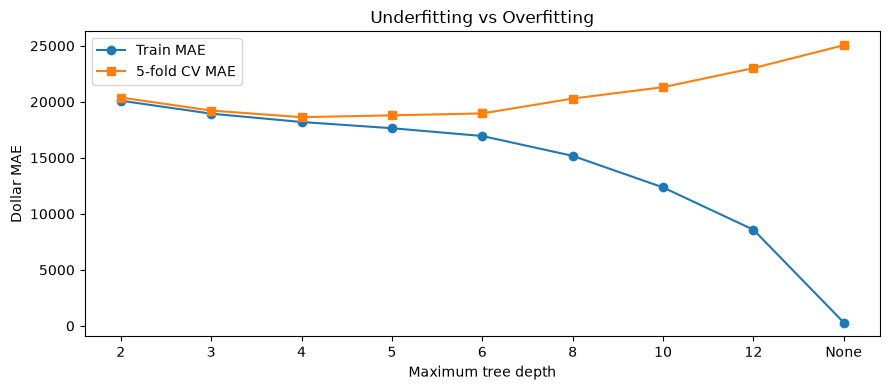

In [59]:
depth_rows=[]
for depth in [2,3,4,5,6,8,10,12,None]:
    model=DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_STATE)
    cv_mean,cv_std=cv_mae_dollars(model,X_train,y_train)
    model.fit(X_train,y_train)
    tr=regression_metrics(y_train,model.predict(X_train))['MAE ($)']
    depth_rows.append({'max_depth':str(depth),'Train MAE ($)':tr,'CV MAE ($)':cv_mean,'CV std ($)':cv_std})
depth_results=pd.DataFrame(depth_rows)
print(depth_results.round(0).to_string(index=False))
plt.figure(figsize=(9,4))
plt.plot(depth_results['max_depth'],depth_results['Train MAE ($)'],marker='o',label='Train MAE')
plt.plot(depth_results['max_depth'],depth_results['CV MAE ($)'],marker='s',label='5-fold CV MAE')
plt.xlabel('Maximum tree depth');plt.ylabel('Dollar MAE');plt.title('Underfitting vs Overfitting');plt.legend();plt.tight_layout();plt.show()

## 5. Hyperparameter tuning — Randomized Search + 5-fold CV
Tune `max_depth` (tree complexity), `min_samples_split` (minimum observations required to split), `min_samples_leaf` (minimum per leaf), and `max_features` (how many predictors considered at each split). **Selection metric:** negative MAE on log-price (built-in and fast). We also independently compute 5-fold **dollar MAE** for the chosen model. Never tune using the held-out test set.

In [60]:
param_dist = {
    'max_depth': [3,4,5,6,7,8,10,12,16,None],
    'min_samples_split': [2,5,10,20,40],
    'min_samples_leaf': [1,2,4,8,12,20],
    'max_features': [None,0.7,0.9]
}
search = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_distributions=param_dist,n_iter=45,scoring='neg_mean_absolute_error',
    cv=cv,random_state=RANDOM_STATE,n_jobs=-1,refit=True,return_train_score=True
)
search.fit(X_train,y_train)
tuned_tree=search.best_estimator_
tuned_cv_mean,tuned_cv_std=cv_mae_dollars(tuned_tree,X_train,y_train)
tuned_train=regression_metrics(y_train,tuned_tree.predict(X_train))
tuned_test=regression_metrics(y_test,tuned_tree.predict(X_test))
print('Selected params:',search.best_params_)
print(f'Best 5-fold CV MAE (log): {-search.best_score_:.4f}')
print(f'Tuned 5-fold CV MAE ($): ${tuned_cv_mean:,.0f} ± ${tuned_cv_std:,.0f}')
print('Tuned test metrics:',tuned_test)
print('Tree depth:',tuned_tree.get_depth(),'leaves:',tuned_tree.get_n_leaves())

Selected params: {'min_samples_split': 40, 'min_samples_leaf': 20, 'max_features': None, 'max_depth': 5}
Best 5-fold CV MAE (log): 0.3946
Tuned 5-fold CV MAE ($): $18,537 ± $1,271
Tuned test metrics: {'MAE ($)': 18820.671432096693, 'RMSE ($)': np.float64(40235.04094152088), 'R2 (log)': 0.6317794005708837, 'MAE (log)': 0.40986229595320745}
Tree depth: 5 leaves: 31


## 6. Baseline vs tuned: measured results
Optimization is a hypothesis, not a guaranteed improvement. Compare both CV and held-out test results and describe what actually happened. Select hyperparameters from training CV, **not** whichever candidate happened to score best on the test set.

                   Model  CV MAE ($)  CV SD ($)  Test MAE ($)  Test RMSE ($)  Test R2 (log)
            Dummy median   26,301.58   1,644.78           NaN            NaN            NaN
Decision Tree — baseline   25,053.92   2,206.67     27,077.26      83,554.46           0.37
   Decision Tree — tuned   18,536.76   1,271.12     18,820.67      40,235.04           0.63


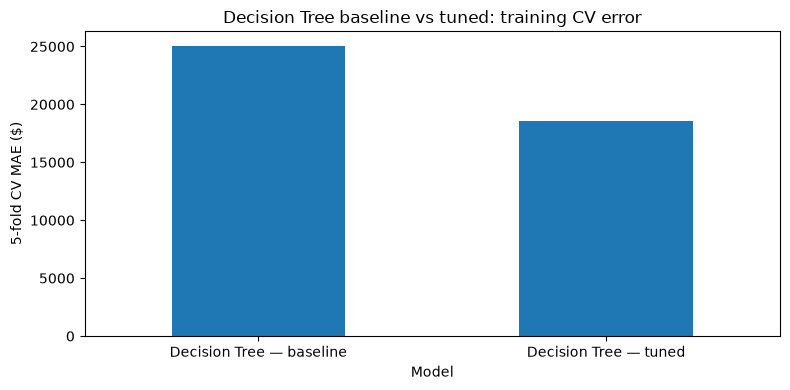

Saved: shaji_decision_tree_model_comparison.csv


In [61]:
comparison = pd.DataFrame([
    {'Model':'Dummy median','CV MAE ($)':dummy_cv_mean,'CV SD ($)':dummy_cv_std,'Test MAE ($)':np.nan,'Test RMSE ($)':np.nan,'Test R2 (log)':np.nan},
    {'Model':'Decision Tree — baseline','CV MAE ($)':base_cv_mean,'CV SD ($)':base_cv_std,'Test MAE ($)':base_test['MAE ($)'],'Test RMSE ($)':base_test['RMSE ($)'],'Test R2 (log)':base_test['R2 (log)']},
    {'Model':'Decision Tree — tuned','CV MAE ($)':tuned_cv_mean,'CV SD ($)':tuned_cv_std,'Test MAE ($)':tuned_test['MAE ($)'],'Test RMSE ($)':tuned_test['RMSE ($)'],'Test R2 (log)':tuned_test['R2 (log)']},
]);print(comparison.round(3).to_string(index=False))
ax=comparison.iloc[1:].plot.bar(x='Model',y='CV MAE ($)',legend=False,figsize=(8,4),rot=0)
ax.set_title('Decision Tree baseline vs tuned: training CV error');ax.set_ylabel('5-fold CV MAE ($)');plt.tight_layout();plt.show()
comparison.to_csv('shaji_decision_tree_model_comparison.csv',index=False)
print('Saved: shaji_decision_tree_model_comparison.csv')

## 7. Feature importance and visualizing the tree
Impurity-based importance is quick, but correlated features (e.g. mileage and mileage/year) can share importance. 
.

Top features (split importance):
milage               0.74
car_age              0.18
is_luxury_brand      0.05
mileage_per_year     0.02
fuel_Gasoline        0.01
is_manual            0.00
is_clean_title       0.00
fuel_E85 Flex Fuel   0.00
has_accident         0.00
fuel_Electric        0.00
dtype: float64


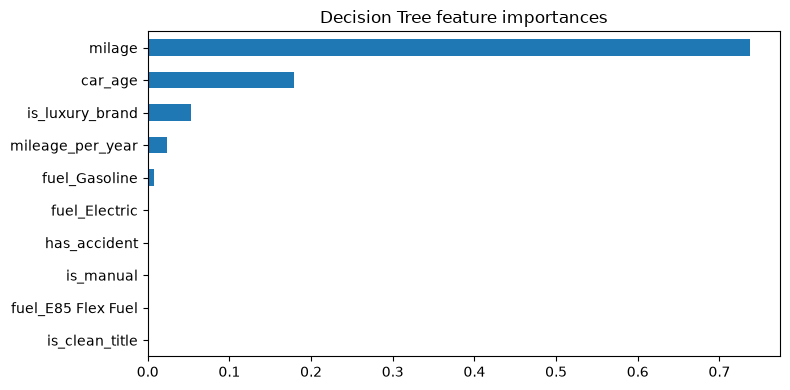

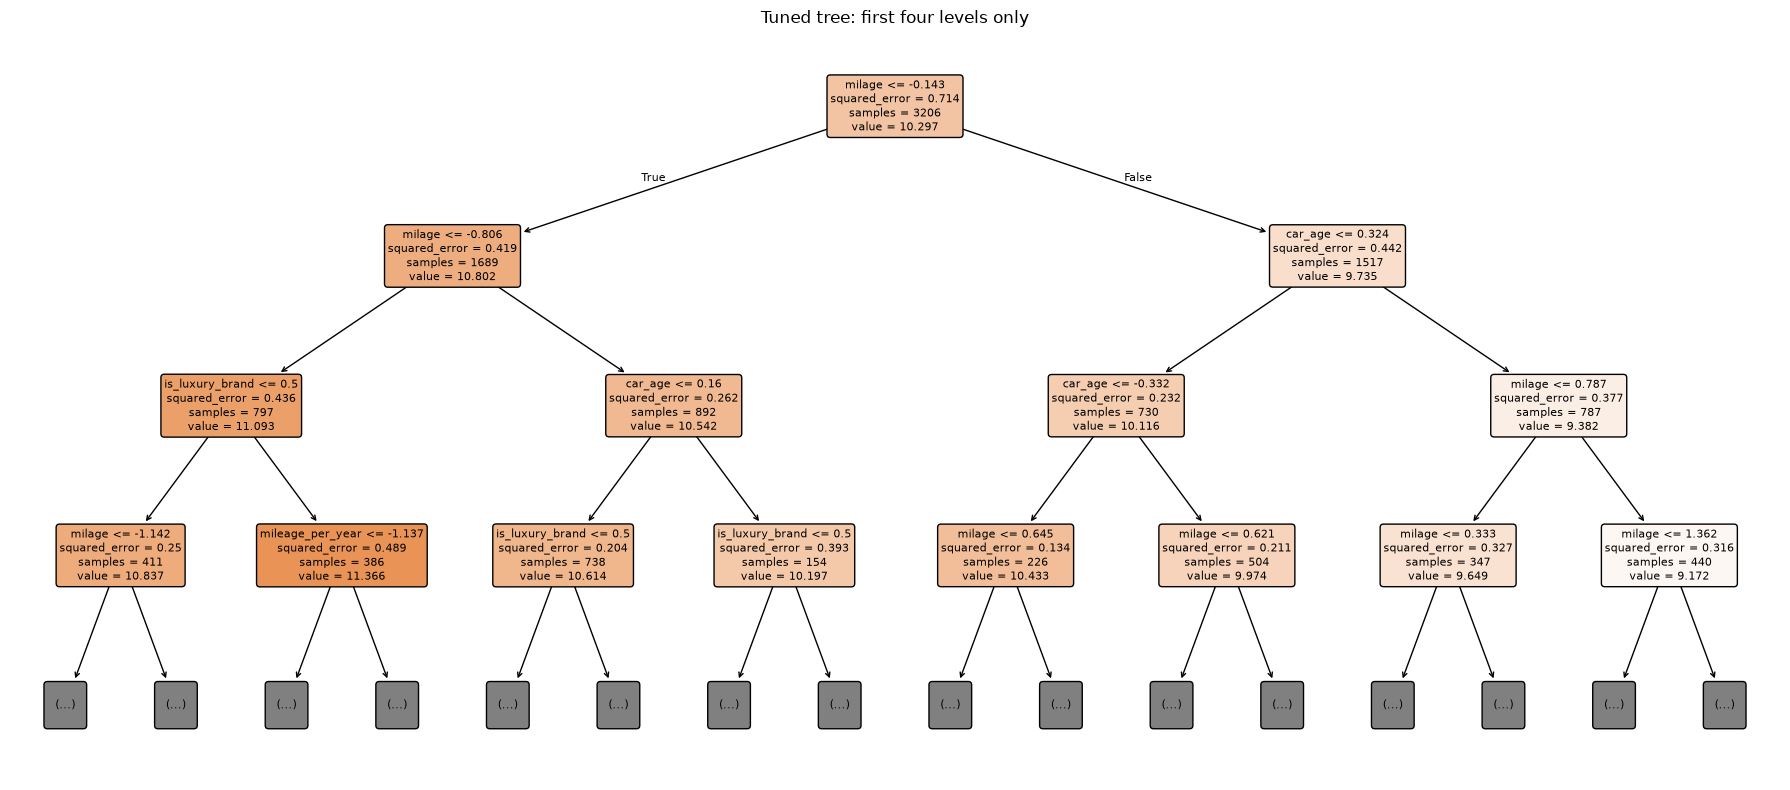

In [62]:
importance=pd.Series(tuned_tree.feature_importances_,index=X_train.columns).sort_values(ascending=False)
print('Top features (split importance):');print(importance.head(10).round(3))
importance.head(10).sort_values().plot.barh(figsize=(8,4),title='Decision Tree feature importances')
plt.tight_layout();plt.show()
plt.figure(figsize=(18,8));plot_tree(tuned_tree,feature_names=list(X_train.columns),max_depth=3,
    filled=True,fontsize=8,rounded=True)
plt.title('Tuned tree: first four levels only');plt.tight_layout();plt.show()

## 8. Feature-engineering experiment — does mileage_per_year help?
Use the same tuned Decision Tree and cross-validation on the same training rows. Compare the original 13-feature set with a version that removes the engineered mileage-per-year predictor. This is a test of feature usefulness, not a test-set optimization.


In [63]:
X_train_without_mpy = X_train.drop(columns=['mileage_per_year'])
no_mpy_cv_mean, no_mpy_cv_std = cv_mae_dollars(tuned_tree, X_train_without_mpy, y_train)
print(f'With mileage_per_year    — CV MAE: ${tuned_cv_mean:,.0f}')
print(f'Without mileage_per_year — CV MAE: ${no_mpy_cv_mean:,.0f}')
if tuned_cv_mean < no_mpy_cv_mean:
    print('The engineered feature improved cross-validation dollar MAE in this experiment.')
else:
    print('The engineered feature did not improve cross-validation dollar MAE in this experiment.')


With mileage_per_year    — CV MAE: $18,537
Without mileage_per_year — CV MAE: $18,649
The engineered feature improved cross-validation dollar MAE in this experiment.


## 9. Predicting a price and saving the model
Select the model based on **training CV**; do not select based on its test score. This is your individual decision tree artifact, **not automatically the group’s final model**. Your group should compare all four algorithms on the same split and metrics before selecting a final system model.

In [64]:
selected_tree = tuned_tree if tuned_cv_mean <= base_cv_mean else base_tree
selected_name = 'Tuned decision tree' if selected_tree is tuned_tree else 'Baseline decision tree'
print('Selected by training CV dollar MAE:',selected_name)
first=X_test.iloc[[0]]
pred_log=float(selected_tree.predict(first)[0]);pred_dollars=np.expm1(pred_log)
actual_dollars=np.expm1(float(y_test.iloc[0]))
print(f'Sample predicted price: ${pred_dollars:,.2f}; actual: ${actual_dollars:,.2f}')
joblib.dump({'model':selected_tree,'feature_cols':feature_cols,'scaling_means':mu,
             'scaling_stds':sigma,'reference_year':2026,'target':'log_price'},
             'shaji_decision_tree_model.joblib')
print('Saved: shaji_decision_tree_model.joblib')

Selected by training CV dollar MAE: Tuned decision tree
Sample predicted price: $39,401.87; actual: $32,500.00
Saved: shaji_decision_tree_model.joblib


## 10. Group comparison table (enter teammates’ ACTUAL test metrics)
No fictitious results. Use the same test rows and feature set for all four algorithms. **For validation/model selection**, also compare 5-fold training-CV MAE. Explain differences: Linear Regression models additive linear relationships; a Decision Tree learns nonlinear threshold interactions; Random Forest averages many randomized trees to reduce variance; Gradient Boosting builds trees sequentially to correct earlier errors. Performance is dataset-dependent.


In [65]:
group_results = pd.DataFrame([
 {'Student':'Adi','Algorithm':'Random Forest','CV MAE ($)':np.nan,'Test MAE ($)':np.nan,'Test RMSE ($)':np.nan,'Test R2 (log)':np.nan},
 {'Student':'Mahee','Algorithm':'Gradient Boosting','CV MAE ($)':np.nan,'Test MAE ($)':np.nan,'Test RMSE ($)':np.nan,'Test R2 (log)':np.nan},
 {'Student':'Shaji','Algorithm':selected_name,'CV MAE ($)':min(base_cv_mean,tuned_cv_mean),
  'Test MAE ($)':regression_metrics(y_test,selected_tree.predict(X_test))['MAE ($)'],
  'Test RMSE ($)':regression_metrics(y_test,selected_tree.predict(X_test))['RMSE ($)'],
  'Test R2 (log)':regression_metrics(y_test,selected_tree.predict(X_test))['R2 (log)']},
 {'Student':'Amandi','Algorithm':'Linear Regression','CV MAE ($)':np.nan,'Test MAE ($)':np.nan,'Test RMSE ($)':np.nan,'Test R2 (log)':np.nan}
])
print(group_results.to_string(index=False))
group_results.to_csv('group_model_comparison_FILL_TEAM_RESULTS.csv',index=False)
print('Ask teammates for actual metrics on the SAME data, split and scale.')

Student           Algorithm  CV MAE ($)  Test MAE ($)  Test RMSE ($)  Test R2 (log)
    Adi       Random Forest         NaN           NaN            NaN            NaN
  Mahee   Gradient Boosting         NaN           NaN            NaN            NaN
  Shaji Tuned decision tree   18,536.76     18,820.67      40,235.04           0.63
 Amandi   Linear Regression         NaN           NaN            NaN            NaN
Ask teammates for actual metrics on the SAME data, split and scale.
